# 42.2 · Variational autoencoders

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain variational autoencoders using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[23 · CNN Fundamentals](../../23-cnn-fundamentals/README.md), [24 · PyTorch for Computer Vision](../../24-pytorch-for-computer-vision/README.md), [39 · Self-Supervised Learning](../../39-self-supervised-learning/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Generative vision learns to reconstruct or synthesize images. An autoencoder compresses observations, a VAE imposes a probabilistic latent structure, and a GAN learns through competition. Understanding their objectives helps explain blur, collapse and unstable training.

## 2. Intuition

A VAE predicts a latent mean and variance and samples using a differentiable reparameterization. Its objective balances reconstruction with a KL penalty toward a prior. Increasing the regularization can improve latent structure while reducing sharpness. The tiny lab uses an MLP VAE on generated shapes.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 42
LESSON = 1
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
z=\mu+\sigma\odot\epsilon,\qquad\epsilon\sim\mathcal N(0,I)
$$

μ and σ are encoder outputs, ε standard-normal noise, ⊙ elementwise multiplication and z the sampled latent vector. With μ=2, σ=0.5 and ε=−1, z=1.5. Gradients can pass through μ and σ.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
mean, standard_deviation, noise = 2.0, 0.5, -1.0
latent = mean + standard_deviation * noise
assert np.isclose(latent, 1.5)
print(latent)

1.5


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The three local modes train an autoencoder, VAE or small GAN and display their actual outputs. Loss curves are optimization observations, not substitutes for diversity or realism evaluation.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def generative(lesson, seed, amount):
    configure(seed)
    x, _, _ = shape_data(64, seed=seed)
    losses = []
    if lesson < 2:
        model = Autoencoder(variational=lesson == 1)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
        for _ in range(35):
            output, mu, logvar = model(x)
            reconstruction = F.mse_loss(output, x)
            kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).mean()
            loss = reconstruction + (0.01 * amount * kl if lesson == 1 else 0)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            losses.append(float(loss.detach()))
        with torch.no_grad():
            samples = model.decoder(torch.randn(4, 12)).reshape(4, 24, 24)
        panels = {
            "Input": x[0, 0].numpy(),
            "Reconstruction": output[0, 0].detach().numpy(),
            "Latent samples": torch.cat(list(samples), 1).numpy(),
        }
        label = "VAE" if lesson else "Autoencoder"
    else:
        generator = nn.Sequential(nn.Linear(12, 64), nn.ReLU(), nn.Linear(64, 576), nn.Sigmoid())
        discriminator = nn.Sequential(nn.Linear(576, 64), nn.LeakyReLU(0.2), nn.Linear(64, 1))
        go = torch.optim.Adam(generator.parameters(), lr=0.002)
        do = torch.optim.Adam(discriminator.parameters(), lr=0.002)
        for _ in range(40):
            fake = generator(torch.randn(64, 12))
            real = x.flatten(1)
            dl = (
                F.softplus(-discriminator(real)).mean()
                + F.softplus(discriminator(fake.detach())).mean()
            )
            do.zero_grad()
            dl.backward()
            do.step()
            gl = F.softplus(-discriminator(generator(torch.randn(64, 12)))).mean()
            go.zero_grad()
            gl.backward()
            go.step()
            losses.append(float(gl.detach()))
        panels = {
            "Real shape": x[0, 0].numpy(),
            "Generator sample": generator(torch.randn(1, 12)).detach().reshape(24, 24).numpy(),
        }
        label = "GAN"
    return Result(
        "42 · " + label + " training and sample inspection",
        panels,
        curves={"Training objective": losses},
        metrics={"updates": len(losses)},
        notes="Short synthetic training demonstrates objectives and data flow, not photorealistic generation or a publication-quality generative score.",
    )

{
  "updates": 35
}
Short synthetic training demonstrates objectives and data flow, not photorealistic generation or a publication-quality generative score.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/models.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.models import Autoencoder

display(Code(inspect.getsource(Autoencoder), language="python"))

class Autoencoder(nn.Module):
    def __init__(self, variational=False):
        super().__init__()
        self.variational = variational
        self.encoder = nn.Sequential(nn.Linear(24 * 24, 64), nn.ReLU())
        self.mu = nn.Linear(64, 12)
        self.logvar = nn.Linear(64, 12)
        self.decoder = nn.Sequential(
            nn.Linear(12, 64), nn.ReLU(), nn.Linear(64, 24 * 24), nn.Sigmoid()
        )

    def forward(self, x):
        hidden = self.encoder(x.flatten(1))
        mu = self.mu(hidden)
        logvar = self.logvar(hidden).clamp(-8, 8)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar) if self.variational else mu
        reconstruction = self.decoder(z).reshape(-1, 1, 24, 24)
        return reconstruction, mu, logvar

## 8. Experiment

Interpolate between two latent codes, vary the VAE KL weight and inspect whether the GAN repeats a few outputs.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "updates": 35
  },
  "second_seed": {
    "updates": 35
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

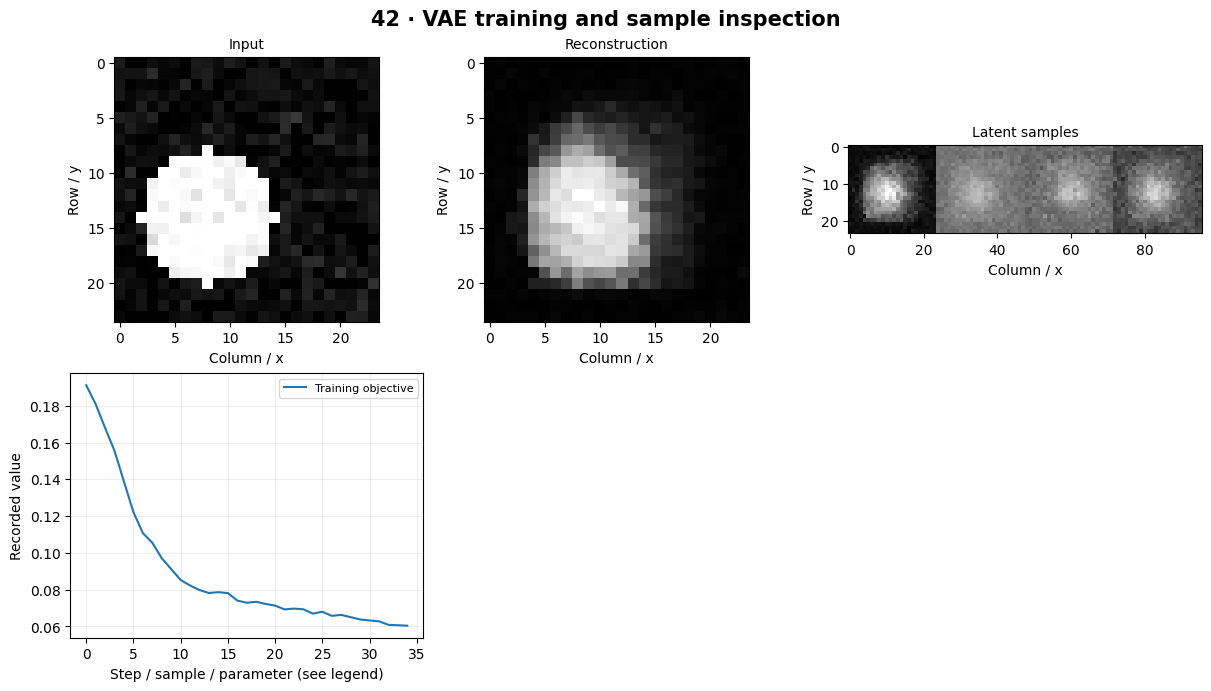

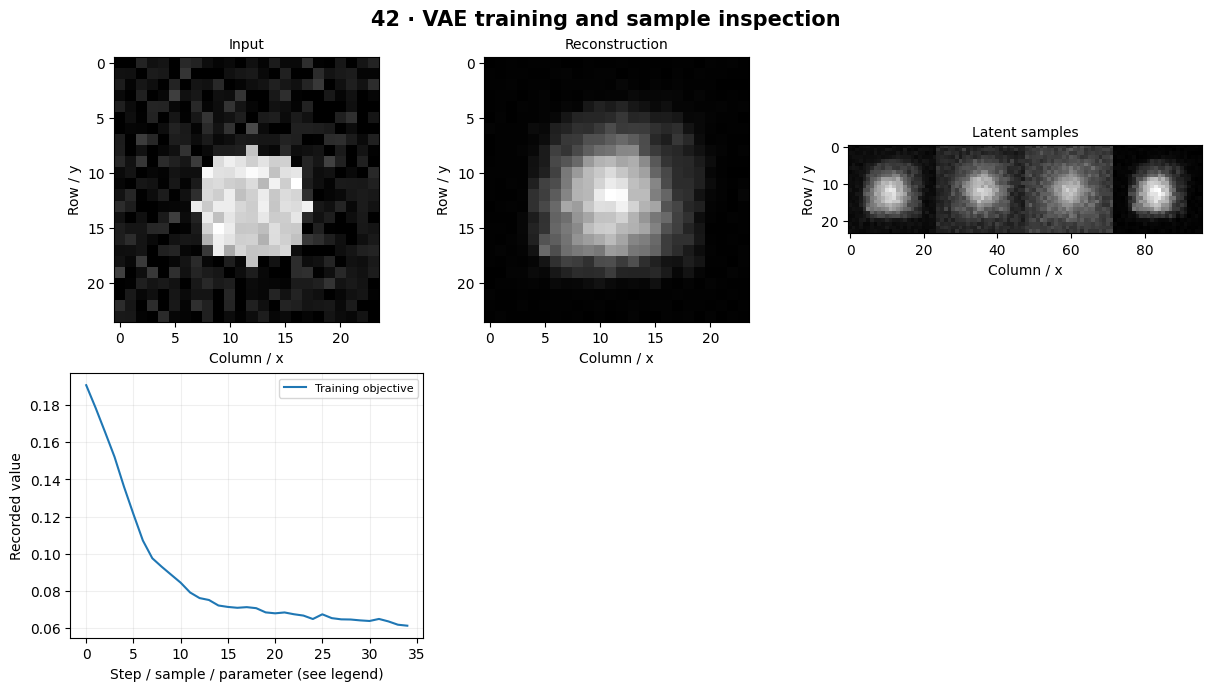

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Generative Shapes Lab**. Separate reconstruction quality from distribution coverage. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Low reconstruction MSE can favor blurry averages. Cherry-picked generated samples do not establish model quality.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Interpolate between two latent codes, vary the VAE KL weight and inspect whether the GAN repeats a few outputs.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Compare reconstruction quality and sample diversity of an AE, VAE and GAN under a documented compute budget.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

A VAE predicts a latent mean and variance and samples using a differentiable reparameterization. Its objective balances reconstruction with a KL penalty toward a prior. Increasing the regularization can improve latent structure while reducing sharpness. The tiny lab uses an MLP VAE on generated shapes.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **GAN objectives and failure analysis** in this chapter.

[Primary reference](https://arxiv.org/abs/1312.6114) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)